C:\Users\Dmitrij Ignat`ev\AppData\Local\Temp\ipykernel_6196\1368109805.py:15: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  import scipy.io


dict_keys(['__header__', '__version__', '__globals__', 'YR', 'MO', 'DY', 'HR', 'MN', 'SC', 'ID', 'Lat', 'Lon', 'Depth', 'Mag', 'Time'])
no of events 1926
completeness 4.6
{'b': np.float64(1.3333398574492394), 'a': np.float64(9.192926762167774), 'Mc': np.float64(4.600000000000003), 'stdDev': np.float64(0.03740030851531001), 'binsize': 0.1}
e:\Work\auto-sub-fault\magnitude-distribution-master


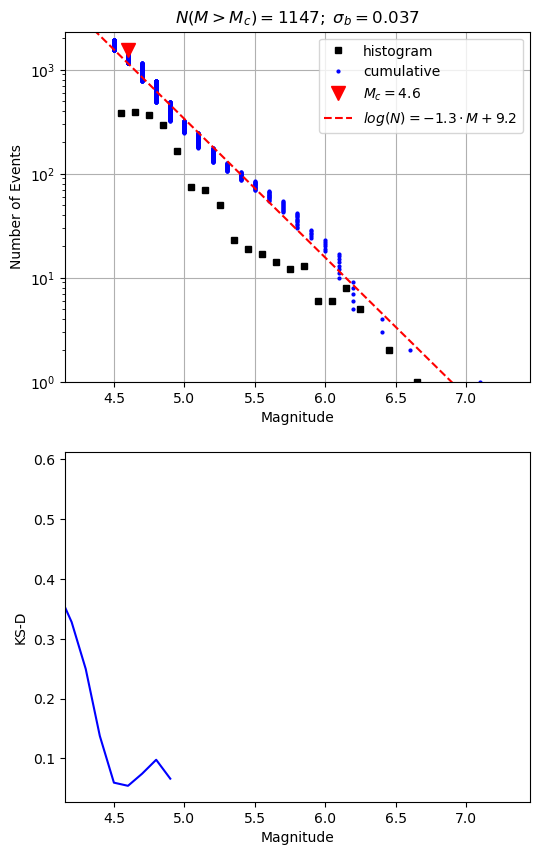

In [ ]:
"""
    - fit mag distribution to So Cal data set from
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

np.random.seed(123456)
#-------fct. / module def-----------------------------------------------

from src.FMD_GR import FMD
oFMD = FMD()


#============================================================================================================
#                             variables and files
#============================================================================================================
dir_in = 'data'
file_in= 'NEIC_Global_1900_2025_2011_Tohoku.mat'

binsize = .1
mc_type = np.arange(1.5, 5, binsize)  #'maxCurvature' 'KS' #'MC'#2.5

#=========================================1==================================================================
#                             load data
#============================================================================================================

dEq = scipy.io.loadmat( f"{dir_in}/{file_in}", struct_as_record=False, squeeze_me=True)
print(  dEq.keys())
oFMD.data['mag'] = dEq['Mag']
print( 'no of events', len( dEq['Mag']))

#=========================================2==================================================================
#                             determine Mc and b usign KS-test
#============================================================================================================
oFMD.mag_dist()
a_RanErr = np.random.randn( len( dEq['Mag'])) * binsize*.4
oFMD.data['mag'] += a_RanErr
oFMD.get_Mc( mc_type = mc_type)
oFMD.data['mag'] -= a_RanErr

print( 'completeness', round( oFMD.par['Mc'], 1))
oFMD.fit_GR( binCorrection = 0)
print( oFMD.par)

#=========================================3==================================================================
#                                plot FMD and KS statistic as fct of Mc
#============================================================================================================
#oFMD.plotDistr()
plt.figure(1, figsize = (6,10))
ax1 = plt.subplot(211)
oFMD.plotFit(ax1)
ax2 = plt.subplot( 212)
oFMD.plotKS( ax2)
ax2.set_xlim( ax1.get_xlim())
plt.savefig( file_in.replace( '.mat', '_fmd.png'))
print( os.getcwd())
#plt.show()